# WHO Life Expectancy Analysis

## 01 - Data Exploration

This notebook explores the WHO Life Expectancy dataset.

The goal is to understand:
- Dataset structure
- Countries and years
- Gender categories
- Life expectancy trends

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/RELAY_WHS.csv")

df.head()

,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,DIM_SEX,AMOUNT_N
0,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,702,COUNTRY,PUBLISHED,Life expectancy (at birth),Singapore,FEMALE,80.774170
1,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,703,COUNTRY,PUBLISHED,Life expectancy (at birth),Slovakia,FEMALE,77.405510
2,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2006,YEAR,462,COUNTRY,PUBLISHED,Life expectancy (at birth),Maldives,FEMALE,75.095393
3,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2006,YEAR,466,COUNTRY,PUBLISHED,Life expectancy (at birth),Mali,FEMALE,56.722839
4,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2006,YEAR,470,COUNTRY,PUBLISHED,Life expectancy (at birth),Malta,FEMALE,81.520700


## Dataset Exploration

In [61]:
df["GEO_NAME_SHORT"].nunique()

df["GEO_NAME_SHORT"].unique()[:20]


<StringArray>
[                   'Singapore',                     'Slovakia',
                     'Maldives',                         'Mali',
                        'Malta',                 'Sierra Leone',
          'Antigua and Barbuda',                       'Angola',
                      'Algeria',                      'Albania',
                  'Afghanistan',                        'World',
                   'Mauritania',                         'Oman',
                      'Namibia',                        'Nepal',
 'Netherlands (Kingdom of the)',                    'Mauritius',
                       'Mexico',                     'Mongolia']
Length: 20, dtype: str

In [62]:
df_total =df[df["DIM_SEX"] =="TOTAL"]
df_total.head()


,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,DIM_SEX,AMOUNT_N
3738,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,8,COUNTRY,PUBLISHED,Life expectancy (at birth),Albania,TOTAL,73.682857
3739,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,12,COUNTRY,PUBLISHED,Life expectancy (at birth),Algeria,TOTAL,72.468391
3756,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,24,COUNTRY,PUBLISHED,Life expectancy (at birth),Angola,TOTAL,49.367744
3757,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,690,COUNTRY,PUBLISHED,Life expectancy (at birth),Seychelles,TOTAL,72.105308
3758,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,694,COUNTRY,PUBLISHED,Life expectancy (at birth),Sierra Leone,TOTAL,49.786490


In [63]:
df["DIM_SEX"] == "TOTAL"

0        False
1        False
2        False
3        False
4        False
         ...  
12931     True
12932     True
12933     True
12934     True
12935     True
Name: DIM_SEX, Length: 12936, dtype: bool

In [64]:
df_total.shape

(4312, 13)

In [65]:
world = df_total[df_total["GEO_NAME_SHORT"] == "world"]
world.head()

,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,DIM_SEX,AMOUNT_N


In [66]:
world[["DIM_TIME","AMOUNT_N"]]

,DIM_TIME,AMOUNT_N


In [67]:
df_total[df_total["GEO_NAME_SHORT"].str.contains("World", case=False)]

,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,DIM_SEX,AMOUNT_N
3760,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,1,GLOBAL,PUBLISHED,Life expectancy (at birth),World,TOTAL,66.770851
5316,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2003,YEAR,1,GLOBAL,PUBLISHED,Life expectancy (at birth),World,TOTAL,67.616580
5766,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2010,YEAR,1,GLOBAL,PUBLISHED,Life expectancy (at birth),World,TOTAL,70.498085
6469,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2015,YEAR,1,GLOBAL,PUBLISHED,Life expectancy (at birth),World,TOTAL,72.185689
6698,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2019,YEAR,1,GLOBAL,PUBLISHED,Life expectancy (at birth),World,TOTAL,73.123374
6794,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2020,YEAR,1,GLOBAL,PUBLISHED,Life expectancy (at birth),World,TOTAL,72.450439
6852,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2009,YEAR,1,GLOBAL,PUBLISHED,Life expectancy (at birth),World,TOTAL,70.218077
9110,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2007,YEAR,1,GLOBAL,PUBLISHED,Life expectancy (at birth),World,TOTAL,69.424659
9233,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2005,YEAR,1,GLOBAL,PUBLISHED,Life expectancy (at birth),World,TOTAL,68.386611
9278,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2006,YEAR,1,GLOBAL,PUBLISHED,Life expectancy (at birth),World,TOTAL,68.984651


In [68]:
world = df_total[df_total["GEO_NAME_SHORT"] == "World"]

world = world.sort_values("DIM_TIME")

world[["DIM_TIME", "AMOUNT_N"]]

,DIM_TIME,AMOUNT_N
3760,2000,66.770851
10776,2001,67.099007
11801,2002,67.358303
5316,2003,67.616580
10857,2004,67.952511
9233,2005,68.386611
9278,2006,68.984651
9110,2007,69.424659
12079,2008,69.700644
6852,2009,70.218077


## Global Life Expectancy Trend

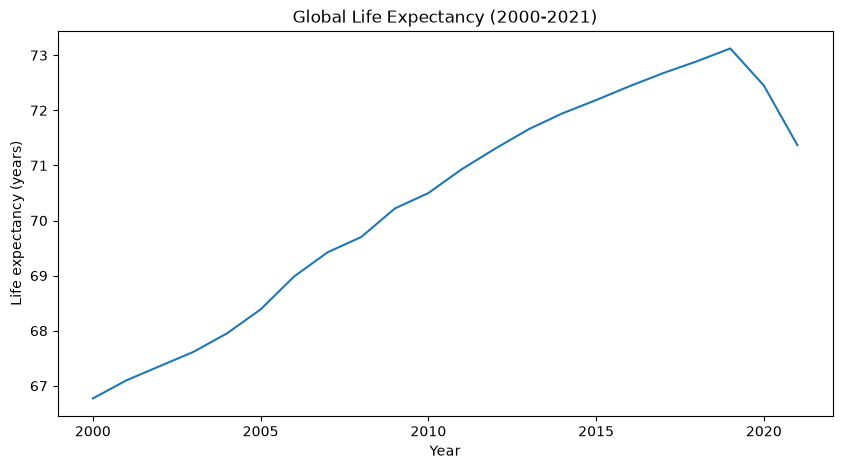

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(world["DIM_TIME"], world["AMOUNT_N"])

plt.xlabel("Year")
plt.ylabel("Life expectancy (years)")
plt.title("Global Life Expectancy (2000-2021)")

plt.show()

## Countries Ranking

In [70]:
country_avg = df_total.groupby("GEO_NAME_SHORT")["AMOUNT_N"].mean()

country_avg.sort_values(ascending=False).head(10)

GEO_NAME_SHORT
Japan          83.205168
Switzerland    81.975752
Australia      81.741702
Singapore      81.686158
Iceland        81.520811
Italy          81.497205
Spain          81.354480
Sweden         81.210192
France         81.034385
Luxembourg     81.018863
Name: AMOUNT_N, dtype: float64

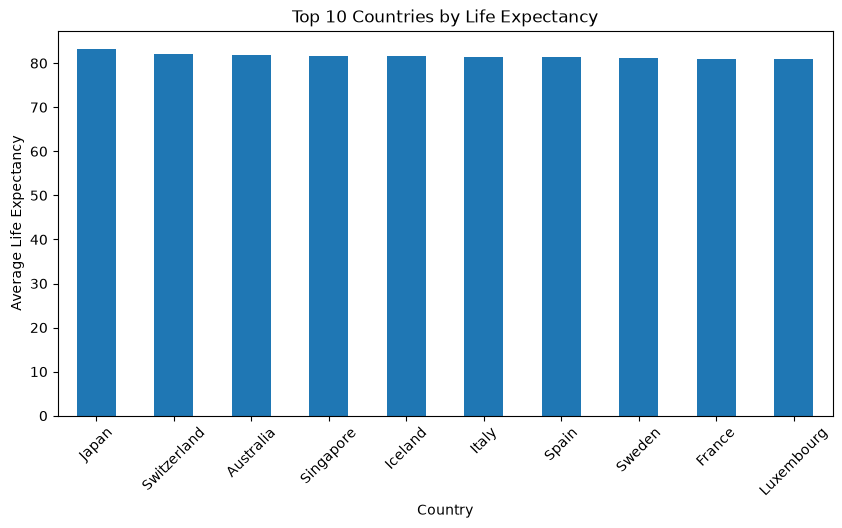

In [71]:
top10 = country_avg.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top10.plot(kind="bar")

plt.xlabel("Country")
plt.ylabel("Average Life Expectancy")
plt.title("Top 10 Countries by Life Expectancy")

plt.xticks(rotation=45)

plt.show()

In [72]:
bottom10 = country_avg.sort_values(ascending=True).head(10)

bottom10

GEO_NAME_SHORT
Lesotho                     47.990378
Eswatini                    48.267392
Central African Republic    48.766881
Somalia                     51.236483
Zimbabwe                    52.084131
Mozambique                  54.214899
Guinea-Bissau               55.130469
Sierra Leone                55.320433
Zambia                      55.494430
Chad                        55.597482
Name: AMOUNT_N, dtype: float64

## Country Comparison

In [73]:
compare = df_total[df_total["GEO_NAME_SHORT"].isin(["Japan", "Lesotho"])]

compare.head()

,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,DIM_SEX,AMOUNT_N
3853,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,392,COUNTRY,PUBLISHED,Life expectancy (at birth),Japan,TOTAL,81.530179
3863,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,426,COUNTRY,PUBLISHED,Life expectancy (at birth),Lesotho,TOTAL,47.381277
4879,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2002,YEAR,392,COUNTRY,PUBLISHED,Life expectancy (at birth),Japan,TOTAL,82.100745
4887,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2002,YEAR,426,COUNTRY,PUBLISHED,Life expectancy (at birth),Lesotho,TOTAL,47.828813
4959,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2004,YEAR,426,COUNTRY,PUBLISHED,Life expectancy (at birth),Lesotho,TOTAL,43.806762


In [74]:
compare = compare.sort_values("DIM_TIME")

compare[["DIM_TIME", "GEO_NAME_SHORT", "AMOUNT_N"]]

,DIM_TIME,GEO_NAME_SHORT,AMOUNT_N
3853,2000,Japan,81.530179
3863,2000,Lesotho,47.381277
8953,2001,Japan,81.842259
9005,2001,Lesotho,47.971324
4887,2002,Lesotho,47.828813
4879,2002,Japan,82.100745
9114,2003,Lesotho,45.645383
9614,2003,Japan,82.140252
9189,2004,Japan,82.370039
4959,2004,Lesotho,43.806762


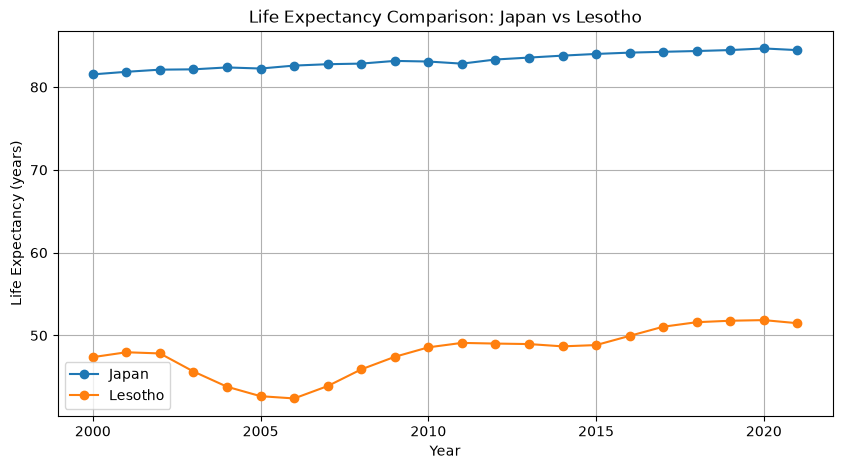

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for country in ["Japan", "Lesotho"]:
    data = compare[compare["GEO_NAME_SHORT"] == country]
    plt.plot(data["DIM_TIME"], data["AMOUNT_N"], marker="o", label=country)

plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.title("Life Expectancy Comparison: Japan vs Lesotho")
plt.legend()
plt.grid(True)

plt.show()

## Data Cleaning and Export

In [76]:
clean_df = df_total[
    [
        "DIM_TIME",
        "GEO_NAME_SHORT",
        "DIM_SEX",
        "IND_NAME",
        "AMOUNT_N"
    ]
]

clean_df.head()

,DIM_TIME,GEO_NAME_SHORT,DIM_SEX,IND_NAME,AMOUNT_N
3738,2000,Albania,TOTAL,Life expectancy (at birth),73.682857
3739,2000,Algeria,TOTAL,Life expectancy (at birth),72.468391
3756,2000,Angola,TOTAL,Life expectancy (at birth),49.367744
3757,2000,Seychelles,TOTAL,Life expectancy (at birth),72.105308
3758,2000,Sierra Leone,TOTAL,Life expectancy (at birth),49.786490


In [77]:
clean_df = clean_df.rename(
    columns={
        "DIM_TIME": "Year",
        "GEO_NAME_SHORT": "Country",
        "DIM_SEX": "Sex",
        "IND_NAME": "Indicator",
        "AMOUNT_N": "Life_expectancy"
    }
)

clean_df.head()

,Year,Country,Sex,Indicator,Life_expectancy
3738,2000,Albania,TOTAL,Life expectancy (at birth),73.682857
3739,2000,Algeria,TOTAL,Life expectancy (at birth),72.468391
3756,2000,Angola,TOTAL,Life expectancy (at birth),49.367744
3757,2000,Seychelles,TOTAL,Life expectancy (at birth),72.105308
3758,2000,Sierra Leone,TOTAL,Life expectancy (at birth),49.786490


In [78]:
clean_df.to_csv("../data/clean/who_life_expectancy_clean.csv", index=False)

In [79]:
import os

os.makedirs("../data/clean", exist_ok=True)

print("clean folder is ready")

clean folder is ready


In [81]:
os.listdir("../data/clean")

['who_life_expectancy_clean.csv']

In [82]:
os.getcwd()

'c:\\Users\\shadi\\OneDrive\\Desktop\\كشكول\\WHO_Data_Project\\notebooks'

In [83]:
import os

print(os.getcwd())

c:\Users\shadi\OneDrive\Desktop\كشكول\WHO_Data_Project\notebooks


In [84]:
os.listdir("../data")

['clean', 'raw']

In [85]:
os.listdir("../data/clean")

['who_life_expectancy_clean.csv']

In [88]:
['who_life_expectancy_clean.csv']

['who_life_expectancy_clean.csv']

In [89]:
import os

os.listdir("../data/clean")

['who_life_expectancy_clean.csv']

## Import Libraries

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

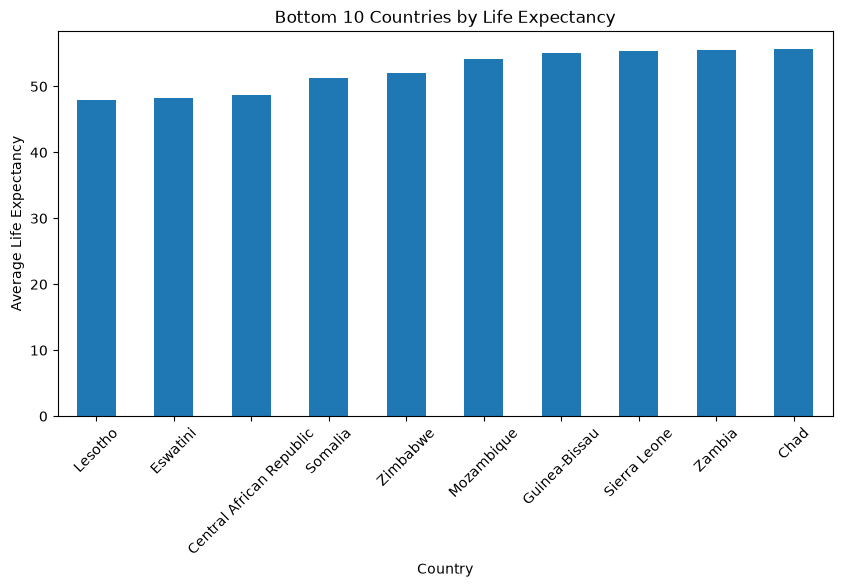

In [91]:
plt.figure(figsize=(10,5))

bottom10.plot(kind="bar")

plt.xlabel("Country")
plt.ylabel("Average Life Expectancy")
plt.title("Bottom 10 Countries by Life Expectancy")

plt.xticks(rotation=45)

plt.show()